In [1]:
# =======================================
# CUSTOMER CHURN PREDICTION (XGBOOST)
# =======================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from xgboost import XGBClassifier

In [2]:
# Load dataset
df = pd.read_csv("cleaned_data/telco_churn_raw.csv")

df["Churn"].unique()




array(['No', 'Yes'], dtype=object)

In [3]:
# -------------------------------
# 2. Data Cleaning
# -------------------------------
#
df.drop("customerID", axis=1, inplace=True)
df.drop("gender", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())




# df.head()

In [4]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})




In [5]:

X = df.drop("Churn", axis=1)
y = df["Churn"]


In [6]:
# numeric_cols = X.select_dtypes(include="number")
#
#
# print(numeric_cols)
# categorical_cols = [col for col in X.select_dtypes(include="object")]
# print(categorical_cols)
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_cols = [col for col in X.columns if col not in numeric_cols]

In [7]:
# -------------------------------
# 5. Preprocessing Pipelines
# -------------------------------
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [8]:
df["Churn"].value_counts(normalize=True)


Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [9]:
scale = (len(df) - df["Churn"].sum()) / df["Churn"].sum()

In [10]:
# -------------------------------
# 6. XGBoost Classifier
# -------------------------------
xgb_model = XGBClassifier(
    scale_pos_weight=scale,
    n_estimators=200,
    learning_rate=0.01,
    max_depth=8,
    subsample=0.7,
    colsample_bytree=0.7,
    objective="binary:logistic",
    eval_metric="logloss"
)

# Build full pipeline
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

In [11]:
# -------------------------------
# 7. Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
# from sklearn.model_selection import GridSearchCV
#
# # 1. Define parameter search space
# param_grid = {
#     "model__max_depth": [4, 6, 8],
#     "model__learning_rate": [0.01, 0.05, 0.1],
#     "model__n_estimators": [200, 300, 500],
#     "model__subsample": [0.7, 0.9, 1.0],
#     "model__colsample_bytree": [0.7, 0.9, 1.0],
# }
#
# # 2. Wrap your pipeline inside GridSearchCV
# grid_search = GridSearchCV(
#     estimator=clf,              # your pipeline
#     param_grid=param_grid,      # hyperparameters to try
#     scoring="f1",               # optimize F1 (best for churn)
#     cv=3,                       # 3-fold cross validation
#     verbose=2,                  # show progress
#     n_jobs=-1                   # use all CPU cores
# )
#
# # 3. Fit the grid search instead of the pipeline
# grid_search.fit(X_train, y_train)
#
# # 4. Best model
# best_model = grid_search.best_estimator_
# print("Best Params:", grid_search.best_params_)

In [13]:
# -------------------------------
# 8. Train the Model
# -------------------------------
clf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
# -------------------------------
# 9. Predictions
# -------------------------------
y_pred = clf.predict(X_test)

In [15]:
# -------------------------------
# 10. Evaluation
# -------------------------------
print("\n=== MODEL PERFORMANCE ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))


=== MODEL PERFORMANCE ===
Accuracy: 0.7601
Precision: 0.5346
Recall: 0.7433
F1 Score: 0.6219

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1035
           1       0.53      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409




=== TOP 20 IMPORTANT FEATURES ===
                               feature  importance
34             Contract_Month-to-month    0.503701
36                   Contract_Two year    0.085109
14         InternetService_Fiber optic    0.054280
16                   OnlineSecurity_No    0.044110
15                  InternetService_No    0.033150
35                   Contract_One year    0.024443
26     TechSupport_No internet service    0.020608
13                 InternetService_DSL    0.020423
25                      TechSupport_No    0.016717
17  OnlineSecurity_No internet service    0.014691
33                 StreamingMovies_Yes    0.013257
20    OnlineBackup_No internet service    0.009494
0                               tenure    0.009272
41      PaymentMethod_Electronic check    0.007820
11      MultipleLines_No phone service    0.007671
30                     StreamingTV_Yes    0.007325
2                         TotalCharges    0.006773
8                      PhoneService_No    0.006

<Figure size 1000x800 with 0 Axes>

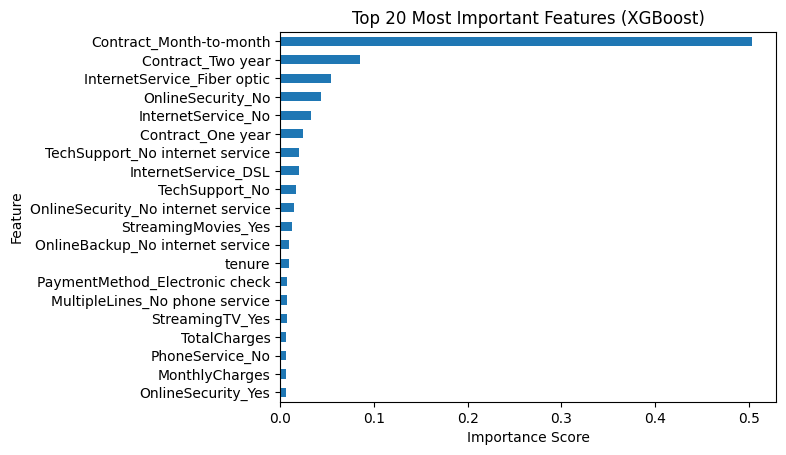

In [16]:
# -------------------------------
# 11. Feature Importance
# -------------------------------
# Extract feature names from preprocessing
onehot_cols = clf.named_steps["preprocessor"].transformers_[1][1] \
    .named_steps["encoder"].get_feature_names_out(categorical_cols)

all_feature_names = numeric_cols + list(onehot_cols)

# Get XGBoost feature importances
importances = clf.named_steps["model"].feature_importances_

# Create a DataFrame
feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\n=== TOP 20 IMPORTANT FEATURES ===")
print(feat_imp.head(20))

# Optional: Plot feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
feat_imp.head(20).plot(kind="barh", x="feature", y="importance", legend=False)
plt.title("Top 20 Most Important Features (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()  # highest on top
plt.show()